In [87]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv", low_memory=False)

In [88]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5

In [89]:
print(df.groupby("Open")["Sales"].mean())
print(df["Open"].value_counts())


Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64
Open
1    844392
0    172817
Name: count, dtype: int64


In [90]:
print(df.groupby("Promo")["Sales"].mean())

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [91]:
print(df.groupby("DayOfWeek")["Sales"].mean())

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


In [92]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [93]:
print(df.groupby("Year")["Sales"].mean())
print(df.groupby("Month")["Sales"].mean())

Year
2013    5658.533675
2014    5833.290704
2015    5878.245380
Name: Sales, dtype: float64
Month
1     5465.395529
2     5645.253150
3     5784.578871
4     5738.866916
5     5489.639973
6     5760.964375
7     6064.915711
8     5693.016554
9     5570.246033
10    5537.037419
11    6008.111821
12    6826.611377
Name: Sales, dtype: float64


In [94]:
print(df.groupby("Store")["Sales"].mean().describe())
print(df.groupby("Store")["Sales"].mean().head(10))


count     1115.000000
mean      5763.320541
std       2046.447377
min       2244.503185
25%       4412.415567
50%       5459.185775
75%       6633.871550
max      20718.515924
Name: Sales, dtype: float64
Store
1     3945.704883
2     4122.991507
3     5741.253715
4     8021.769639
5     3867.110403
6     4562.375796
7     7356.902335
8     4610.251592
9     5426.816348
10    4634.439490
Name: Sales, dtype: float64


In [95]:
test = pd.read_csv("test.csv", low_memory=False)

print(test.columns)

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='str')


In [96]:
df = df.drop(columns=["Customers"])
# customers  رو حذف میکنیم چون در فایل تست نیست

In [97]:
df["DayOfMonth"] = df["Date"].dt.day

In [98]:
df = df.drop(columns=["Date"])

In [99]:
print(df["StateHoliday"].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [100]:
df["StateHoliday"] = df["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})

In [101]:
df["StateHoliday"] = df["StateHoliday"].astype(str)

df["StateHoliday"] = df["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})

In [102]:
df = pd.read_csv("train.csv", low_memory=False)

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfMonth"] = df["Date"].dt.day

df["StateHoliday"] = df["StateHoliday"].astype(str)

print(df["StateHoliday"].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [103]:
df["StateHoliday"] = df["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})

print(df["StateHoliday"].value_counts())
print(df.isnull().sum())

StateHoliday
0    986159
1     20260
2      6690
3      4100
Name: count, dtype: int64
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
Year             0
Month            0
Day              0
DayOfMonth       0
dtype: int64


In [104]:
df = df.drop(columns=["Date", "Customers"])

In [105]:
x = df.drop(columns=["Sales"])
y = df["Sales"]

In [106]:
print(x.head())
print(x.shape)
print(y.shape)
print(x.isnull().sum().sum())

   Store  DayOfWeek  Open  Promo  StateHoliday  SchoolHoliday  Year  Month  \
0      1          5     1      1             0              1  2015      7   
1      2          5     1      1             0              1  2015      7   
2      3          5     1      1             0              1  2015      7   
3      4          5     1      1             0              1  2015      7   
4      5          5     1      1             0              1  2015      7   

   Day  DayOfMonth  
0   31          31  
1   31          31  
2   31          31  
3   31          31  
4   31          31  
(1017209, 10)
(1017209,)
0


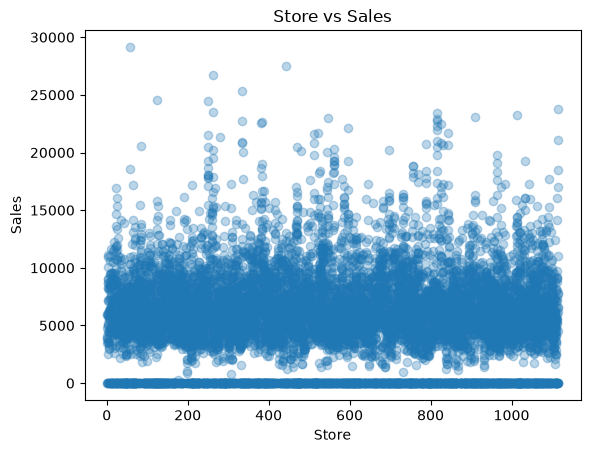

In [107]:
import matplotlib.pyplot as plt

sample = df.sample(10000, random_state=42)

plt.scatter(sample["Store"], sample["Sales"], alpha=0.3)
plt.xlabel("Store")
plt.ylabel("Sales")
plt.title("Store vs Sales")
plt.show()

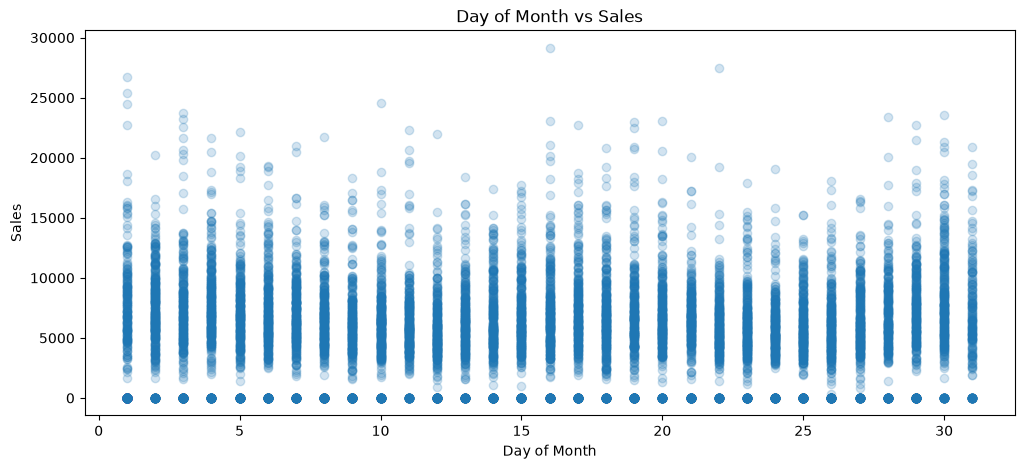

In [108]:
plt.figure(figsize=(12, 5))

sample = df.sample(10000, random_state=42)

plt.scatter(sample["DayOfMonth"], sample["Sales"], alpha=0.2)

plt.xlabel("Day of Month")
plt.ylabel("Sales")
plt.title("Day of Month vs Sales")

plt.show()

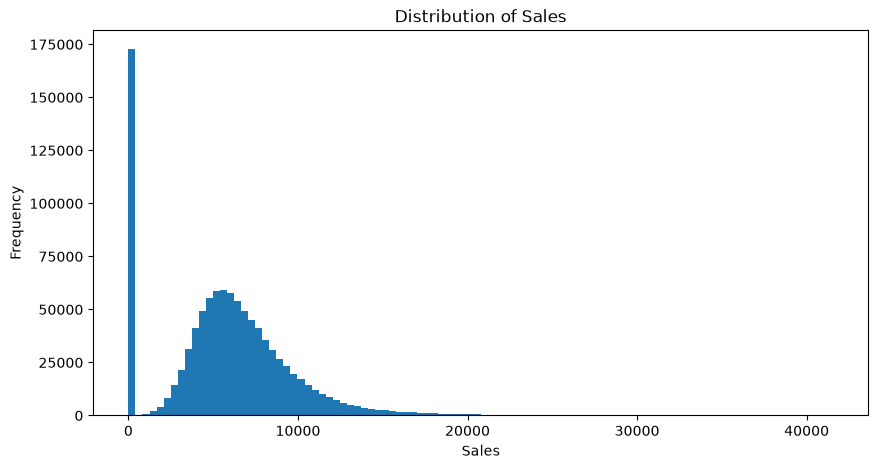

In [109]:
plt.figure(figsize=(10, 5))

plt.hist(df["Sales"], bins=100)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")

plt.show()

In [110]:
x = df.drop(columns=["Sales"])
y = df["Sales"]


In [111]:
y_log = np.log1p(y)

In [112]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x,
    y_log,
    test_size=0.2,
    random_state=42
)



In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

In [114]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=20
)

dt.fit(x_train, y_train)

dt_pred_log = dt.predict(x_val)

dt_pred = np.expm1(dt_pred_log)
dt_pred = np.maximum(dt_pred, 0)

In [115]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred_log = rf.predict(x_val)

rf_pred = np.expm1(rf_pred_log)
rf_pred = np.maximum(rf_pred, 0)

In [116]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(x_train_scaled, y_train)

knn_pred_log = knn.predict(x_val_scaled)

knn_pred = np.expm1(knn_pred_log)
knn_pred = np.maximum(knn_pred, 0)

In [117]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

y_val_real = np.expm1(y_val)

dt_rmsle = np.sqrt(mean_squared_log_error(y_val_real, dt_pred))
rf_rmsle = np.sqrt(mean_squared_log_error(y_val_real, rf_pred))
knn_rmsle = np.sqrt(mean_squared_log_error(y_val_real, knn_pred))

print("Decision Tree RMSLE:", dt_rmsle)
print("Random Forest RMSLE:", rf_rmsle)
print("KNN RMSLE:", knn_rmsle)

Decision Tree RMSLE: 0.3355220222672063
Random Forest RMSLE: 0.3120599961895558
KNN RMSLE: 0.37588640650715655


In [118]:
print(x.columns)

Index(['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'Year', 'Month', 'Day', 'DayOfMonth'],
      dtype='str')


In [119]:
test = pd.read_csv("test.csv", low_memory=False)

print(test.head())
print(test.columns)

   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0   1      1          4  2015-09-17   1.0      1            0              0
1   2      3          4  2015-09-17   1.0      1            0              0
2   3      7          4  2015-09-17   1.0      1            0              0
3   4      8          4  2015-09-17   1.0      1            0              0
4   5      9          4  2015-09-17   1.0      1            0              0
Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='str')


In [120]:
test["Date"] = pd.to_datetime(test["Date"])

test["Year"] = test["Date"].dt.year
test["Month"] = test["Date"].dt.month
test["Day"] = test["Date"].dt.day
test["DayOfMonth"] = test["Date"].dt.day

In [121]:
test["StateHoliday"] = test["StateHoliday"].astype(str)

test["StateHoliday"] = test["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})

In [122]:
test = test.drop(columns=["Date"])

In [123]:
test = test[x.columns]

In [124]:
print(test.columns)
print(test.shape)
print(test.isnull().sum())

Index(['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'Year', 'Month', 'Day', 'DayOfMonth'],
      dtype='str')
(41088, 10)
Store             0
DayOfWeek         0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
Year              0
Month             0
Day               0
DayOfMonth        0
dtype: int64


In [125]:
print(test[test["Open"].isna()])

       Store  DayOfWeek  Open  Promo  StateHoliday  SchoolHoliday  Year  \
479      622          4   NaN      1             0              0  2015   
1335     622          3   NaN      1             0              0  2015   
2191     622          2   NaN      1             0              0  2015   
3047     622          1   NaN      1             0              0  2015   
4759     622          6   NaN      0             0              0  2015   
5615     622          5   NaN      0             0              0  2015   
6471     622          4   NaN      0             0              0  2015   
7327     622          3   NaN      0             0              0  2015   
8183     622          2   NaN      0             0              0  2015   
9039     622          1   NaN      0             0              0  2015   
10751    622          6   NaN      0             0              0  2015   

       Month  Day  DayOfMonth  
479        9   17          17  
1335       9   16          16  
219

In [126]:
train_raw = pd.read_csv("train.csv", low_memory=False)

print(
    train_raw[train_raw["Store"] == 622][
        ["Date", "DayOfWeek", "Open", "Promo", "Sales"]
    ].tail(20)
)

               Date  DayOfWeek  Open  Promo  Sales
995531   2013-01-20          7     0      0      0
996646   2013-01-19          6     1      0   2352
997761   2013-01-18          5     1      0   3355
998876   2013-01-17          4     1      0   3554
999991   2013-01-16          3     1      0   3181
1001106  2013-01-15          2     1      0   3586
1002221  2013-01-14          1     1      0   3574
1003336  2013-01-13          7     0      0      0
1004451  2013-01-12          6     1      0   2131
1005566  2013-01-11          5     1      1   4923
1006681  2013-01-10          4     1      1   4402
1007796  2013-01-09          3     1      1   3913
1008911  2013-01-08          2     1      1   4833
1010026  2013-01-07          1     1      1   5887
1011141  2013-01-06          7     0      0      0
1012256  2013-01-05          6     1      0   2350
1013371  2013-01-04          5     1      0   3675
1014486  2013-01-03          4     1      0   4085
1015601  2013-01-02          3 

In [127]:
print(
    train_raw[train_raw["Store"] == 622]["Open"].value_counts()
)


Open
1    784
0    158
Name: count, dtype: int64


In [128]:
test["Open"] = test["Open"].fillna(1)

In [129]:
print(test["Open"].isna().sum())

0


In [130]:
rf.fit(x, y_log)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [133]:
test_pred_log = rf.predict(test)

test_pred = np.expm1(test_pred_log)
test_pred = np.maximum(test_pred, 0)

print(test_pred[:10])

[5497.46104162 6813.701951   6766.88253024 6723.50426203 6723.50426203
 6723.50426203 6739.54130747 6739.54130747 6739.54130747 6727.6565441 ]


In [136]:
test_raw = pd.read_csv("test.csv", low_memory=False)

print(test_raw.columns)
print(test_raw.head())

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='str')
   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0   1      1          4  2015-09-17   1.0      1            0              0
1   2      3          4  2015-09-17   1.0      1            0              0
2   3      7          4  2015-09-17   1.0      1            0              0
3   4      8          4  2015-09-17   1.0      1            0              0
4   5      9          4  2015-09-17   1.0      1            0              0


In [138]:
output = pd.DataFrame({
    "datetime": test_raw["Date"],
    "count": test_pred
})

In [139]:
print(output.head())
print(output.shape)

     datetime        count
0  2015-09-17  5497.461042
1  2015-09-17  6813.701951
2  2015-09-17  6766.882530
3  2015-09-17  6723.504262
4  2015-09-17  6723.504262
(41088, 2)


In [140]:
output.to_csv("csv.output", index=False)

print("File created successfully!")

File created successfully!


In [141]:
check = pd.read_csv("csv.output")

print(check.head())
print(check.shape)
print(check.columns)

     datetime        count
0  2015-09-17  5497.461042
1  2015-09-17  6813.701951
2  2015-09-17  6766.882530
3  2015-09-17  6723.504262
4  2015-09-17  6723.504262
(41088, 2)
Index(['datetime', 'count'], dtype='str')


In [142]:
print(output["count"].describe())
print(output["count"].isna().sum())
print((output["count"] < 0).sum())


count    41088.000000
mean      5634.344560
std       2747.871187
min          0.000000
25%       5226.348711
50%       5877.654389
75%       7055.238034
max      29818.273968
Name: count, dtype: float64
0
0


In [144]:
output.to_csv("output.csv", index=False)